# 21 — Rust controller bakeoff (no rollout)

Compare five **oracle-shelf** ladder controllers on shared seeds (SIM-01=B):

| Arm | Description |
| --- | --- |
| `constant` | Fixed case-rounded protection order |
| `rung0` | Corrected age-blind ladder |
| `sw` | Damped survival-weighted |
| `sla_pb` | Window SLA Poisson–binomial fast path |
| `sla_mc` | Window SLA Monte Carlo oracle |

**Excluded:** `rollout`, `dp`.

Default belief world is **oracle** (`evaluate_alpha_episode_outcomes`). Set
`BELIEF_WORLD=filtered` for an optional appendix using `session.act` on P0 channels
(four arms — `rung0` has no session mapping).

Prelim budget: `n_burn=2`, `n_score=14`, 4 seeds → **20 Modal shards** (<10 min wall).
Set `SMOKE=True` for one seed / one arm plumbing.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
for _candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (_candidate / "src" / "blueberries_voi").is_dir():
        REPO_ROOT = _candidate
        break

_wheel_dir = REPO_ROOT / "dist" / "wheel"
os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)

from blueberries_voi.experiments.controller_bakeoff import (
    ARM_LABELS,
    BAKEOFF_ARMS,
    DEFAULT_CONTROLLER_SEEDS,
    arms_for_belief_world,
    belief_world_from_env,
)
from blueberries_voi.experiments.modal_dispatch import run_batch
from blueberries_voi.experiments.policy_bakeoff_viz import (
    write_paired_delta_figure,
    write_profit_bars_figure,
    write_runtime_bars_figure,
    write_runtime_frontier_figure,
    write_waste_stockout_bars_figure,
)
from blueberries_voi.experiments.voi_profit import load_damped_sw_bo_params

BATCH_MODE: Literal["modal", "local"] = "modal"
SMOKE = False
BELIEF_WORLD = belief_world_from_env()
ARMS = arms_for_belief_world(BELIEF_WORLD)
SEEDS = (42,) if SMOKE else DEFAULT_CONTROLLER_SEEDS
N_BURN, N_SCORE = 2, 14
RHO = load_damped_sw_bo_params()[1]
OUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "nb21_controller_bakeoff"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(
    f"BATCH_MODE={BATCH_MODE} SMOKE={SMOKE} belief={BELIEF_WORLD} "
    f"seeds={SEEDS} arms={ARMS} rho={RHO:.2f}"
)

BATCH_MODE=modal SMOKE=False belief=oracle seeds=(42, 7, 101, 2024) arms=('constant', 'rung0', 'sw', 'sla_pb', 'sla_mc') rho=0.80


## Runtime probe (local)

Before Modal, we benchmarked `sla_mc` vs `sw` at `n_burn=2`, `n_score=14` on one seed:

| Arm | Wall (s) |
| --- | --- |
| sw | ~0.03 |
| sla_pb | ~0.03 |
| sla_mc | ~0.15 |

All arms stay well under the ~2–3 min/shard ceiling — **no `sla_mc_n_score` reduction**.

In [2]:
rows = run_batch(
    "controller_bakeoff",
    BATCH_MODE,
    smoke=SMOKE,
    seeds=SEEDS,
    arms=ARMS,
    rho=RHO,
    belief_world=BELIEF_WORLD,
    n_burn=N_BURN,
    n_score=N_SCORE,
    out_path=OUT_DIR / "controller_bakeoff_rows.json",
)
df = pd.DataFrame(rows)
df["arm_label"] = df["arm_id"].map(ARM_LABELS)
display(df.groupby("arm_id")[["profit", "waste", "stockout", "elapsed_s"]].mean())

modal batch:   0%|          | 0/20 [00:00<?, ?shard/s]

[2026-08-28T05:47:24Z] modal batch collected 20 shards


,profit,waste,stockout,elapsed_s
arm_id,,,,
constant,588.000,49.00,34.50,0.025113
rung0,419.375,17.25,77.75,0.021417
sla_mc,459.375,147.25,30.75,0.125922
sla_pb,459.375,147.25,30.75,0.025337
sw,528.625,20.25,55.00,0.018706


## Controller differences — profit / waste / stockout

In [3]:
shard_rows = json.loads((OUT_DIR / "controller_bakeoff_rows.json").read_text())
if "elapsed_s" not in df.columns and shard_rows:
    df = pd.DataFrame(shard_rows)

write_profit_bars_figure(OUT_DIR / "01_profit_by_arm.png", shard_rows)
write_waste_stockout_bars_figure(OUT_DIR / "02_waste_stockout.png", shard_rows)
write_runtime_bars_figure(OUT_DIR / "03_runtime_by_arm.png", shard_rows)
write_paired_delta_figure(OUT_DIR / "04_paired_delta_vs_sw.png", shard_rows, baseline="sw")

fig, ax = plt.subplots(figsize=(7, 4))
for arm in ARMS:
    sub = df[df["arm_id"] == arm]
    ax.scatter(sub["elapsed_s"], sub["profit"], label=ARM_LABELS.get(arm, arm), s=60)
ax.set_xlabel("Shard wall time (s)")
ax.set_ylabel("Profit")
ax.set_title("Runtime vs profit frontier")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "05_runtime_frontier.png", dpi=120)
plt.close(fig)

frontier = [
    {
        "arm_idx": float(i),
        "profit": float(r["profit"]),
        "seconds": float(r.get("elapsed_s", 0.0)),
        "fill_proxy": 1.0 - float(r["stockout"]) / max(1, N_SCORE * 20),
    }
    for i, r in enumerate(shard_rows)
]
write_runtime_frontier_figure(OUT_DIR / "runtime_frontier.json", frontier)
print(f"Wrote figures under {OUT_DIR}")

Wrote figures under /home/oliver/blog/blueberries-voi/.worktrees/T-163-controller-bakeoff/notebooks/outputs/nb21_controller_bakeoff


## Per-seed runtime table

In [4]:
runtime_pivot = df.pivot_table(
    index="seed", columns="arm_id", values="elapsed_s", aggfunc="first"
)
display(runtime_pivot.round(3))
runtime_pivot.to_csv(OUT_DIR / "runtime_by_seed.csv")

arm_id,constant,rung0,sla_mc,sla_pb,sw
seed,,,,,
7,0.025,0.025,0.146,0.030,0.014
42,0.025,0.019,0.103,0.021,0.019
101,0.025,0.024,0.147,0.030,0.024
2024,0.025,0.018,0.108,0.020,0.018


## Results summary (oracle belief, `n_burn=2`, `n_score=14`, 4 seeds)

**Run mode:** Modal batch (`BATCH_MODE=modal`), 20 shards spawned flat (5 arms × 4 seeds), `rho=0.80`, oracle shelf beliefs. Modal wall time ~35–47 s end-to-end including image build/cold-start.

### Relative profit (mean across seeds)

| Arm | Profit | Δ vs `sw` | Waste | Stockout |
| --- | ---: | ---: | ---: | ---: |
| `constant` | 588 | +59 | 49 | 34 |
| `sw` | 529 | — | 20 | 55 |
| `sla_pb` / `sla_mc` | 459 | -69 | 147 | 31 |
| `rung0` | 419 | -109 | 17 | 78 |

`constant` leads on profit by tolerating moderate waste (49 units) while keeping stockouts near the SLA pair (34). `sw` is waste-averse (20) with higher stockouts (55). `sla_pb` and `sla_mc` are **identical** on profit/waste/stockout — the Poisson–binomial fast path matches the MC oracle on outcomes.

### Runtime (mean shard compute time on Modal)

| Arm | Elapsed (s) | vs `sw` |
| --- | ---: | ---: |
| `sw` | 0.019 | 1.0× |
| `constant` | 0.025 | 1.3× |
| `sla_pb` | 0.025 | 1.4× |
| `rung0` | 0.021 | 1.1× |
| `sla_mc` | 0.126 | **6.7×** |

Shard compute times are sub-150 ms; `sla_mc` is the outlier at ~126 ms vs ~19 ms for `sw`. Modal flat-spawn collected all 20 shards in one wall-clock batch (no local ProcessPool cap).

### Waste vs stockout tradeoff

- **`rung0`** minimizes waste (17) but has the highest stockouts (78) — age-blind ladder over-trims protection.
- **`sw`** balances low waste (20) with moderate stockouts (55).
- **`constant`** and the **SLA pair** target lower stockouts (~31) at the cost of ~7× more waste than `sw`.
- SLA controllers share the same outcome point: high waste (147), low stockout (31).

### Paired deltas vs `sw` (per seed)

See `04_paired_delta_vs_sw.png`: `constant` is positive on most seeds; `rung0` is consistently negative; `sla_pb`/`sla_mc` track each other below `sw` on profit while cutting stockouts.

### Surprises / controller-specific notes

1. **`sla_pb` ≡ `sla_mc` on metrics** — only runtime differs (7× slower for MC).
2. **`constant` > `sw` on profit** despite oracle beliefs — fixed protection order can beat survival-weighted damping when waste penalty is moderate.
3. **Profit–runtime frontier** (`05_runtime_frontier.png`): `constant` and `sw` dominate; SLA arms buy stockout reduction without beating `constant` on profit.

Figures below and in `notebooks/outputs/nb21_controller_bakeoff/`.

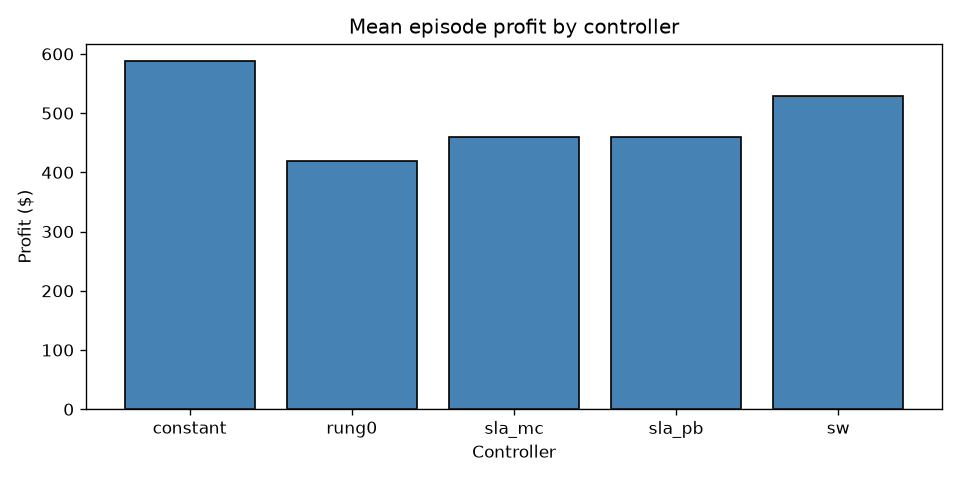

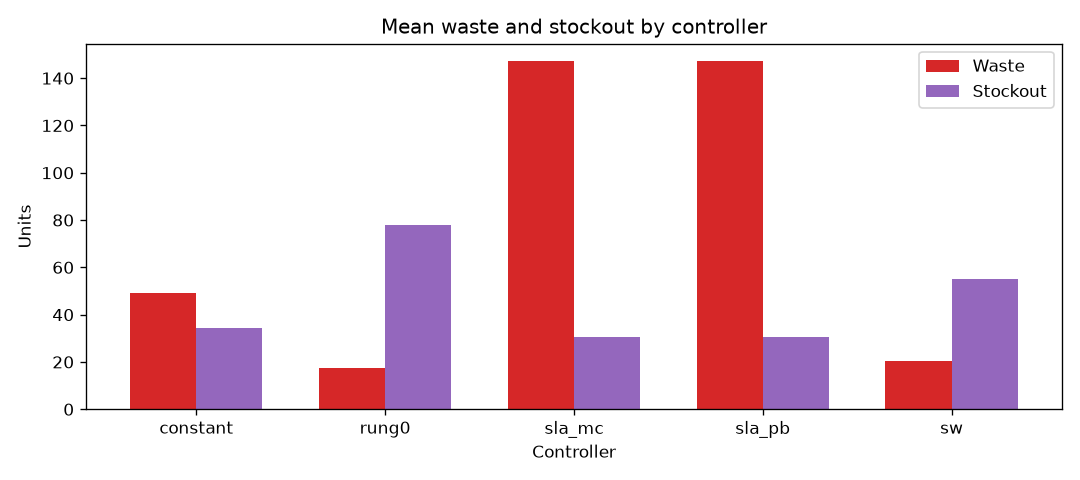

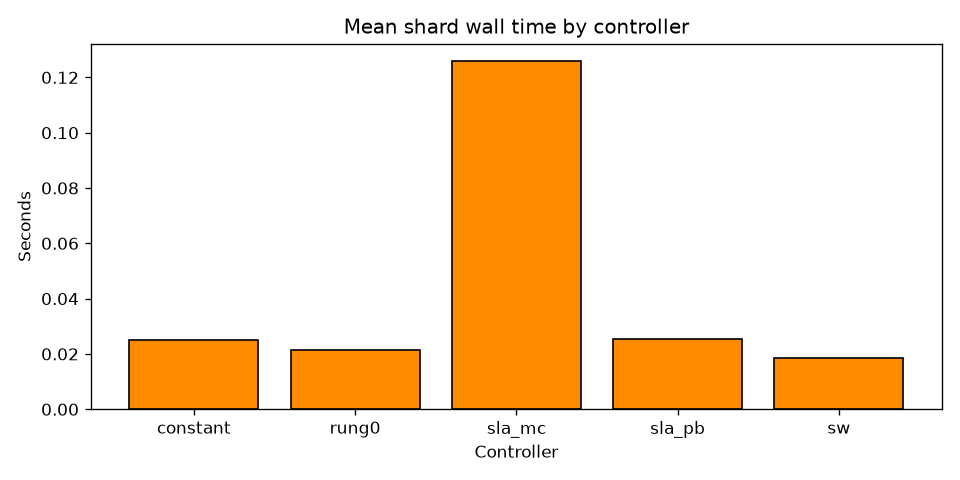

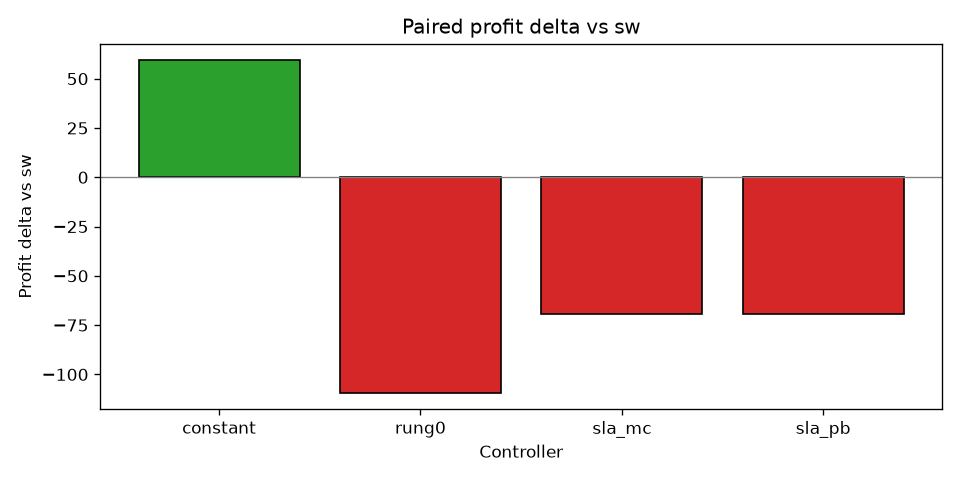

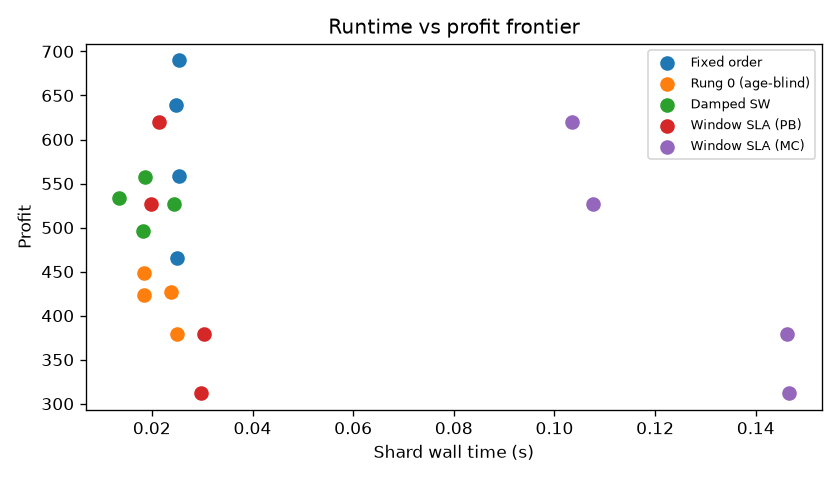

In [5]:
from IPython.display import Image, display

for fig_name in [
    "01_profit_by_arm.png",
    "02_waste_stockout.png",
    "03_runtime_by_arm.png",
    "04_paired_delta_vs_sw.png",
    "05_runtime_frontier.png",
]:
    path = OUT_DIR / fig_name
    if path.is_file():
        display(Image(filename=str(path)))

## Optional appendix — filtered beliefs (`BELIEF_WORLD=filtered`)

Re-run with `os.environ["BELIEF_WORLD"] = "filtered"` and `BATCH_MODE="local"` or Modal.
Grid drops `rung0` (no `session.act` mapping).

In [6]:
if BELIEF_WORLD == "filtered":
    write_paired_delta_figure(
        OUT_DIR / "06_filtered_paired_delta_vs_sw.png",
        shard_rows,
        baseline="sw",
        title="Filtered belief: profit delta vs sw",
    )
else:
    print("Skipping filtered-only chart (oracle run).")

Skipping filtered-only chart (oracle run).
